# Data Quarantine & Diagnostics
Visually and statistically check the raw CSVs in `data/raw/` before modelling.
All paths are relative to the project root (`pemfc-gp/`).

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# --- Locate project root (directory containing src/ and data/) -------------
def _find_project_root():
    start_dirs = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        start_dirs.append(os.path.dirname(os.path.realpath(nb)))
    start_dirs.append(os.getcwd())
    for start in start_dirs:
        d = os.path.abspath(start)
        for _ in range(10):
            if os.path.isdir(os.path.join(d, "src")) and os.path.isdir(os.path.join(d, "data")):
                return d
            d = os.path.dirname(d)
    raise RuntimeError("Cannot find pemfc-gp project root (expected src/ and data/)")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

from src.data_parser import load_and_sanitize_data

try:
    X_train, y_train = load_and_sanitize_data("data/raw/")
    print(f"Loaded {len(y_train)} observations.")
except Exception as e:
    print(f"FATAL: {e}")

In [2]:
# --- Boundary audit --------------------------------------------------------
loading, rh, voltage = X_train[:, 0], X_train[:, 1], y_train
print("--- DATA BOUNDARY AUDIT ---")

if np.any((loading < 0.0) | (loading > 10.0)):
    print("⚠️  TiO2 Loading outside [0, 10] mg/cm².")
else:
    print("✅ TiO2 Loading within sane limits.")

if np.any((rh < 0) | (rh > 100)):
    print("⚠️  Relative Humidity outside [0%, 100%].")
else:
    print("✅ Relative Humidity within [0%, 100%].")

if np.any(voltage < 0):
    print("⚠️  Negative voltages detected.")
else:
    print(f"✅ Voltage: max = {np.max(voltage):.3f} V, no negatives.")

--- DATA BOUNDARY AUDIT ---
✅ TiO2 Loading within sane limits.
✅ Relative Humidity within [0%, 100%].
✅ Voltage: max = 0.633 V, no negatives.


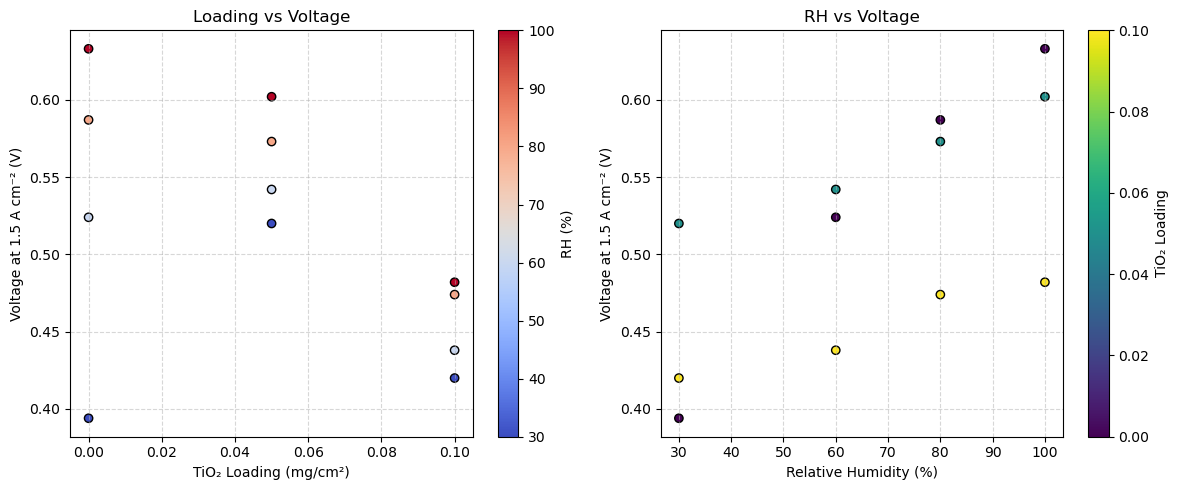

In [3]:
# --- Scatter plots for visual outlier inspection ---------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc1 = ax1.scatter(loading, voltage, c=rh, cmap="coolwarm", edgecolors="k")
ax1.set(title="Loading vs Voltage", xlabel="TiO₂ Loading (mg/cm²)",
        ylabel="Voltage at 1.5 A cm⁻² (V)")
ax1.grid(True, ls="--", alpha=0.5)
fig.colorbar(sc1, ax=ax1, label="RH (%)")

sc2 = ax2.scatter(rh, voltage, c=loading, cmap="viridis", edgecolors="k")
ax2.set(title="RH vs Voltage", xlabel="Relative Humidity (%)",
        ylabel="Voltage at 1.5 A cm⁻² (V)")
ax2.grid(True, ls="--", alpha=0.5)
fig.colorbar(sc2, ax=ax2, label="TiO₂ Loading")

plt.tight_layout()
plt.show()